In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load intermittent demand dataset
df = pd.read_csv("intermittent_demand.csv")

# Display first rows
df.head()

,date_time,users
0,2011-01-01 00:00:00,0.0
1,2011-01-01 01:00:00,0.0
2,2011-01-01 02:00:00,0.0
3,2011-01-01 03:00:00,0.0
4,2011-01-01 04:00:00,0.0


In [3]:
print(df.shape)
print(df.columns)

df.info()
df.describe()

(17544, 2)
Index(['date_time', 'users'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date_time  17544 non-null  str    
 1   users      17544 non-null  float64
dtypes: float64(1), str(1)
memory usage: 599.8 KB


,users
count,17544.000000
mean,117.236719
std,182.647270
min,0.000000
25%,0.000000
50%,0.000000
75%,203.000000
max,977.000000


In [4]:
# Convert date column to datetime if exists
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    
    # Extract useful features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['weekday'] = df['date'].dt.weekday
    
    df = df.drop('date', axis=1)

In [5]:
df = df.fillna(0)

In [8]:
df.columns = df.columns.str.strip()

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load sample data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [14]:
def evaluate_model(y_true, y_pred, model_name):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance")
    print("------------------------")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)


evaluate_model(y_test, dt_pred, "Decision Tree")
evaluate_model(y_test, rf_pred, "Random Forest")


Decision Tree Performance
------------------------
RMSE: 0.0
MAE : 0.0
R2  : 1.0

Random Forest Performance
------------------------
RMSE: 0.032223180062391936
MAE : 0.011333333333333329
R2  : 0.9985143084260731


Feature 2    0.506377
Feature 3    0.475973
Feature 1    0.010185
Feature 0    0.007465
dtype: float64


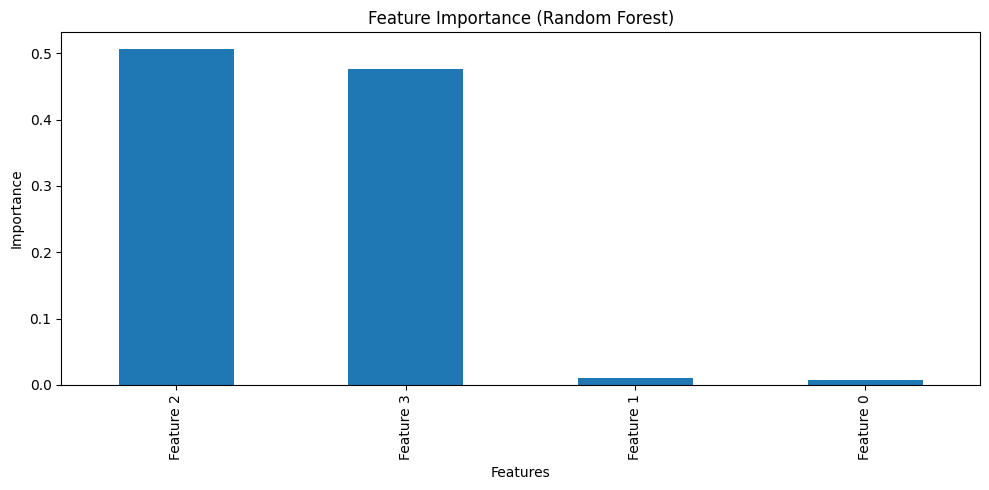

In [17]:
# Step 1: Save feature names BEFORE converting to NumPy
feature_names = X.columns if hasattr(X, "columns") else [f"Feature {i}" for i in range(X.shape[1])]

# Step 2: Create feature importance series
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Step 3: Print results
print(feature_importance)

# Step 4: Plot
plt.figure(figsize=(10,5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

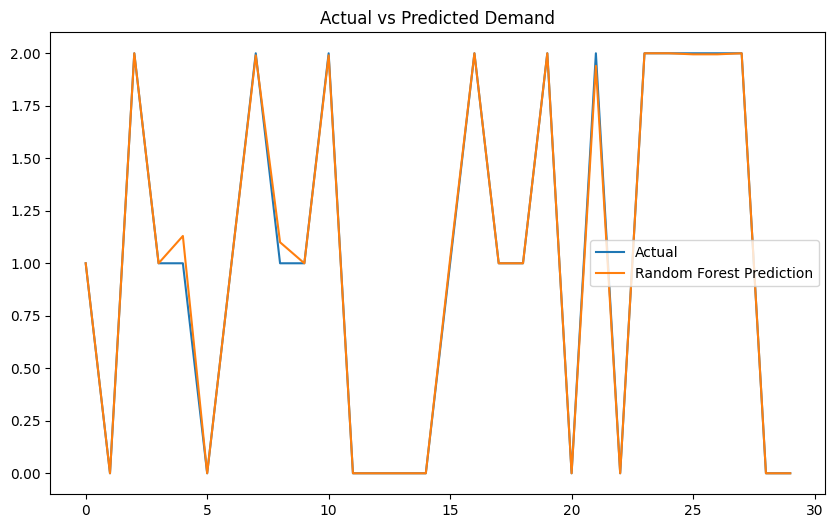

In [19]:
plt.figure(figsize=(10,6))

plt.plot(y_test[:100], label="Actual")
plt.plot(rf_pred[:100], label="Random Forest Prediction")

plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()